# Spectral Filter Optimization

Notebook version of `scripts/spectral_filter_optimization.py`. We demonstrate how to co-design an array of spectral filters and a simple neural network decoder for computational spectroscopy.

### Outline

0. **Imports** for optics, data manipulation, and Flax neural networks.
1. **Paths and Parameters** for the dataset and optimization config.
2. **MLP Decoder Model** to reconstruct spectra from noisy camera measurements.
3. **Helper Functions** to load hyperspectral data, build a PCA basis, and constrain filter transmission.
4. **Setup** of the optical module simulating an array of filters on a camera.
5. **Proxy Loss and Optimization** using Fisher Information and D-optimality for fast filter initialization.
6. **Hybrid Model Loss and Optimization** to jointly fine-tune the filter array and MLP decoder end-to-end.
7. **Evaluation** of reconstruction accuracy on the validation set.
8. **Plot Results** for the optimized filter transmission spectra and example reconstructions.


## 0  Imports


In [1]:
from __future__ import annotations

# NOTEBOOK_REPO_ROOT_SETUP
import os
from pathlib import Path as _Path
%matplotlib inline

def _find_repo_root(start: _Path) -> _Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "fouriax").exists()
            and (candidate / "README.md").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate repository root from current working directory. "
        "Expected to find src/fouriax and README.md in an ancestor."
    )

REPO_ROOT = _find_repo_root(_Path.cwd())
if _Path.cwd() != REPO_ROOT:
    os.chdir(REPO_ROOT)


## 1  Paths and Parameters


In [2]:
import json
from pathlib import Path
from typing import Sequence

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from flax import linen as nn
from scipy.io import loadmat
from sklearn.decomposition import PCA

from fouriax.analysis import d_optimality, fisher_information
from fouriax.optics import (
    AmplitudeMask,
    DetectorArray,
    Field,
    Grid,
    OpticalModule,
    PoissonNoise,
    Spectrum,
)
from fouriax.optim import (
    optimize_dataset_hybrid_module,
    optimize_dataset_optical_module,
    train_val_split,
)

DATA_PATH = Path('data/meta_atoms/indian_pines/Indian_pines.mat')
WAVELENGTHS_PATH = Path('data/meta_atoms/indian_pines/wavelengths.npy')
ARTIFACTS_DIR = Path('artifacts')
PLOT_PATH = ARTIFACTS_DIR / "spectral_filter_overview.png"
SUMMARY_PATH = ARTIFACTS_DIR / "spectral_filter_summary.json"

SEED = 0
SPECTRAL_SLICE_START = 40
SPECTRAL_SLICE_STOP = 190
ARRAY_SIZE = 3
PHOTON_SCALE = 200.0

PCA_COMPONENTS = 16
PROXY_BATCH_SIZE = 512
PROXY_EPOCHS = 100
PROXY_LR = 0.005

VAL_FRACTION = 0.05
RECON_BATCH_SIZE = 512
RECON_EPOCHS = 100
RECON_DECODER_LR = 0.0008
RECON_FILTER_LR = 0.08
SMOOTHNESS_REG = 0.02
UNITY_REG = 1e-05
HIDDEN_DIMS = (128, 256, 384, 384)
PLOT = True


## 2  MLP Decoder Model


In [3]:
class SpectralReconMLP(nn.Module):
    hidden_dims: Sequence[int]
    out_dim: int

    @nn.compact
    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        for hidden_dim in self.hidden_dims:
            x = nn.Dense(int(hidden_dim))(x)
            x = nn.relu(x)
        return nn.Dense(self.out_dim)(x)


## 3  Helper Functions

### Filter intensity parameterisation

We parameterise the filter amplitude $a(\lambda)$ at each wavelength using an unbounded
variable $x$. To ensure physical validity (intensity transmission between 0 and 1),
we apply a sigmoid function $\sigma(x)$. The returned value is the intensity transmission:

$$
I(\lambda) = \sigma(x)^2
$$

### Filter smoothness regularisation

Real spectral filters typically do not have infinitely sharp edges. We encourage the
optimised filters to be physically realisable by penalising the mean squared difference
between adjacent wavelength channels for the filter intensity:

$$
\mathcal{L}_{\text{smooth}} = \frac{1}{N_{\lambda}-1} \sum_{i=1}^{N_{\lambda}-1} \bigl(I(\lambda_{i+1}) - I(\lambda_i)\bigr)^2
$$


In [4]:
def load_indian_pines(
    DATA_PATH: Path,
    WAVELENGTHS_PATH: Path,
    *,
    spectral_slice_start: int,
    spectral_slice_stop: int,
) -> tuple[np.ndarray, np.ndarray]:
    data = loadmat(DATA_PATH)
    if "indian_pines" not in data:
        raise KeyError("expected key 'indian_pines' in Indian_pines.mat")
    cube = np.asarray(data["indian_pines"], dtype=np.float32)
    spectra = cube.reshape(-1, cube.shape[-1])[:, spectral_slice_start:spectral_slice_stop]
    wavelengths_nm = np.asarray(np.load(WAVELENGTHS_PATH), dtype=np.float32)[
        spectral_slice_start:spectral_slice_stop
    ]
    order = np.argsort(wavelengths_nm)
    wavelengths_nm = wavelengths_nm[order]
    spectra = spectra[:, order]
    spectra_norm = spectra / np.maximum(np.max(spectra, axis=1, keepdims=True), 1e-12)
    return spectra_norm, wavelengths_nm


def build_pca_basis(
    train_spectra: np.ndarray, n_components: int, seed: int
) -> tuple[PCA, np.ndarray]:
    pca = PCA(n_components=n_components, svd_solver="full", random_state=seed)
    pca.fit(train_spectra)
    basis = np.asarray(pca.components_.T, dtype=np.float32)  # (L, r)
    return pca, basis


def filter_intensity_matrix(raw_filter: jnp.ndarray) -> jnp.ndarray:
    amp = jax.nn.sigmoid(raw_filter)
    return (amp * amp).astype(jnp.float32)


def filter_smoothness(raw_filter: jnp.ndarray) -> jnp.ndarray:
    a = filter_intensity_matrix(raw_filter)
    return jnp.mean((a[:, 1:] - a[:, :-1]) ** 2)


## 4  Setup


In [5]:
spectra_full, wavelengths_nm = load_indian_pines(
    DATA_PATH,
    WAVELENGTHS_PATH,
    spectral_slice_start=SPECTRAL_SLICE_START,
    spectral_slice_stop=SPECTRAL_SLICE_STOP,
)
spectra_full = spectra_full[np.sum(spectra_full, axis=1) > 0.0]
split_rng = np.random.default_rng(SEED)
(train_full,), (val_full,) = train_val_split(
    spectra_full,
    val_fraction=VAL_FRACTION,
    rng=split_rng,
)
train = jnp.asarray(train_full, dtype=jnp.float32)
val = jnp.asarray(val_full, dtype=jnp.float32)

n_wavelengths = int(train.shape[1])
num_filters = int(ARRAY_SIZE**2)
array_size = int(round(np.sqrt(num_filters)))
grid = Grid.from_extent(nx=array_size, ny=array_size, dx_um=1.0, dy_um=1.0)
spectrum = Spectrum.from_array(jnp.asarray(wavelengths_nm * 1e-3, dtype=jnp.float32))
noise_model = PoissonNoise(count_scale=PHOTON_SCALE)

pca_components = min(PCA_COMPONENTS, n_wavelengths, train.shape[0])
pca, basis_np = build_pca_basis(train, pca_components, SEED)
basis = jnp.asarray(basis_np, dtype=jnp.float32)
signal_prior_cov = jnp.asarray(
    np.asarray(pca.explained_variance_, dtype=np.float32),
    dtype=jnp.float32,
)

key = jax.random.PRNGKey(SEED)
raw_filter = jax.random.normal(key, (num_filters, n_wavelengths), dtype=jnp.float32)
proxy_optimizer = optax.adam(PROXY_LR)
proxy_eval_subset = jnp.asarray(
    train[
        : min(
            max(PROXY_BATCH_SIZE * 4, PROXY_BATCH_SIZE),
            train.shape[0],
        )
    ],
    dtype=jnp.float32,
)

def build_filter_module(raw_filter_params: jnp.ndarray) -> OpticalModule:
    a = filter_intensity_matrix(raw_filter_params)
    amp_map = jnp.sqrt(jnp.clip(a.T, 0.0, 1.0)).reshape((spectrum.size, array_size, array_size))
    return OpticalModule(
        layers=(),
        sensor=DetectorArray(
            detector_grid=grid,
            filter_mask=AmplitudeMask(amplitude_map=amp_map),
            noise_model=noise_model,
        ),
    )

def build_sample_field(sample_spectra: np.ndarray | jnp.ndarray) -> Field:
    sample_spectra = jnp.asarray(sample_spectra, dtype=jnp.float32)
    if sample_spectra.ndim == 1:
        sample_spectra = sample_spectra[None, :]
    sample_amp = jnp.sqrt(jnp.maximum(sample_spectra, 0.0)).reshape(
        (sample_spectra.shape[0], spectrum.size, 1, 1)
    )
    field_data = (
        jnp.ones(
            (sample_spectra.shape[0], spectrum.size, array_size, array_size),
            dtype=jnp.complex64,
        )
        * sample_amp
    )
    return Field(data=field_data, grid=grid, spectrum=spectrum, domain="spatial")

def measure_batch(
    raw_filter: jnp.ndarray,
    batch_spectra: np.ndarray | jnp.ndarray,
    *,
    noise_keys: np.ndarray | jnp.ndarray | None = None,
) -> jnp.ndarray:
    module = build_filter_module(raw_filter)
    field = build_sample_field(batch_spectra)
    sensor = module.sensor
    if not isinstance(sensor, DetectorArray):
        raise ValueError("filter module must use DetectorArray for batched measurement")

    image_clean = sensor.expected(field).astype(jnp.float32)
    if noise_keys is None:
        image = image_clean
    else:
        noise_keys = jnp.asarray(noise_keys, dtype=jnp.uint32)
        if noise_keys.ndim == 1:
            noise_keys = noise_keys[None, :]
        image = jax.vmap(
            lambda clean_sample, sample_key: noise_model.sample(clean_sample, key=sample_key)
        )(image_clean, noise_keys)
    return image.reshape((image.shape[0], -1))


## 5  Proxy Loss and Optimization

End-to-end optimization of the joint physical-digital system can be slow and sensitive
to initialization. We first optimize the filters using a fast, physics-informed **proxy metric**:
the **D-optimality** of the Fisher Information matrix.

Assuming the underlying spectra can be represented by a few PCA components $c$, the
measurements $y$ through the filter intensities $A$ are $y \approx A B c$, where $B$
is the PCA basis matrix. The Fisher Information $\mathcal{I}(c)$ quantifies the
information the noisy measurements carry about $c$. We maximize D-optimality
(the log-determinant of the Fisher Information plus the prior covariance), which is
equivalent to minimizing the volume of the uncertainty ellipsoid on the reconstruction.

$$
\mathcal{L}_{\text{proxy}} = - \mathcal{D}_{\text{opt}}(\mathcal{I}(c), \Sigma_{\text{prior}}) + \gamma_{\text{smooth}}\,\mathcal{L}_{\text{smooth}} + \gamma_{\text{unity}}\,\mathcal{L}_{\text{unity}}
$$

The unity regularisation term penalises intensities deviating from $1.0$, encouraging high overall transmission.


In [6]:
def batch_proxy_loss(
    raw_filter: jnp.ndarray,
    batch_spectra: tuple[np.ndarray | jnp.ndarray] | np.ndarray | jnp.ndarray,
) -> jnp.ndarray:
    if isinstance(batch_spectra, tuple):
        if len(batch_spectra) != 1:
            raise ValueError(
                "proxy optimization expects a single spectra array per minibatch"
            )
        batch_spectra = batch_spectra[0]
    a = filter_intensity_matrix(raw_filter)
    ab = a @ basis
    batch_spectra = jnp.asarray(batch_spectra, dtype=jnp.float32)
    batch_coeffs = batch_spectra @ basis
    d_opt = jnp.mean(
        jax.vmap(
            lambda coeffs: d_optimality(
                fisher_information(
                    lambda c: ab @ c,
                    coeffs,
                    noise_model=noise_model,
                ),
                prior_covariance=signal_prior_cov,
            )
        )(batch_coeffs)
    )
    regularization = SMOOTHNESS_REG * filter_smoothness(raw_filter) + UNITY_REG * jnp.mean(
        (filter_intensity_matrix(raw_filter) - 1.0) ** 2
    )
    return -d_opt + regularization

proxy_result = optimize_dataset_optical_module(
    init_params=raw_filter,
    build_module=build_filter_module,
    batch_loss_fn=batch_proxy_loss,
    optimizer=proxy_optimizer,
    train_data=train,
    batch_size=PROXY_BATCH_SIZE,
    epochs=PROXY_EPOCHS,
    val_data=proxy_eval_subset,
    seed=SEED,
)


epoch=001 step=00039 train_loss=-6.728056 val_loss=-6.664504 [best]
epoch=002 step=00079 train_loss=-7.182491 val_loss=-7.330990 [best]
epoch=003 step=00119 train_loss=-8.138075 val_loss=-8.029587 [best]


epoch=004 step=00159 train_loss=-8.536233 val_loss=-8.649520 [best]
epoch=005 step=00199 train_loss=-9.215463 val_loss=-9.179242 [best]
epoch=006 step=00239 train_loss=-9.656259 val_loss=-9.623298 [best]


epoch=007 step=00279 train_loss=-10.123258 val_loss=-9.988332 [best]
epoch=008 step=00319 train_loss=-10.029580 val_loss=-10.286790 [best]
epoch=009 step=00359 train_loss=-10.224924 val_loss=-10.531606 [best]


epoch=010 step=00399 train_loss=-10.547259 val_loss=-10.733682 [best]
epoch=011 step=00439 train_loss=-10.858193 val_loss=-10.901756 [best]
epoch=012 step=00479 train_loss=-10.902441 val_loss=-11.043120 [best]


epoch=013 step=00519 train_loss=-11.106983 val_loss=-11.163820 [best]
epoch=014 step=00559 train_loss=-11.401420 val_loss=-11.268679 [best]
epoch=015 step=00599 train_loss=-11.713348 val_loss=-11.360915 [best]


...

epoch=088 step=03519 train_loss=-12.473476 val_loss=-12.536606 [best]
epoch=089 step=03559 train_loss=-12.713941 val_loss=-12.540734 [best]
epoch=090 step=03599 train_loss=-12.480180 val_loss=-12.546067 [best]


epoch=091 step=03639 train_loss=-12.776746 val_loss=-12.551717 [best]
epoch=092 step=03679 train_loss=-12.336330 val_loss=-12.556942 [best]
epoch=093 step=03719 train_loss=-12.251722 val_loss=-12.561451 [best]


epoch=094 step=03759 train_loss=-12.279891 val_loss=-12.565650 [best]
epoch=095 step=03799 train_loss=-12.550818 val_loss=-12.570035 [best]
epoch=096 step=03839 train_loss=-12.780362 val_loss=-12.574498 [best]


epoch=097 step=03879 train_loss=-12.408946 val_loss=-12.578424 [best]
epoch=098 step=03919 train_loss=-12.347426 val_loss=-12.581562 [best]
epoch=099 step=03959 train_loss=-12.739156 val_loss=-12.584078 [best]


epoch=100 step=03999 train_loss=-12.894055 val_loss=-12.586165 [best]


## 6  Hybrid Model Loss and Optimization

With the filters pre-optimized using the D-optimality proxy, we now jointly
fine-tune both the **optical filters** and the **MLP decoder** end-to-end.

The loss here is the Mean Squared Error (MSE) between the ground-truth
spectrum $x$ and the reconstructed spectrum $\hat{x}$ produced by the MLP
from the noisy camera measurements, plus the same physical regularisation terms
as before:

$$
\mathcal{L}_{\text{hybrid}} = \text{MSE}(x, \hat{x}) + \gamma_{\text{smooth}}\,\mathcal{L}_{\text{smooth}} + \gamma_{\text{unity}}\,\mathcal{L}_{\text{unity}}
$$


In [7]:
raw_filter = proxy_result.params_result.best_params
best_proxy_loss = proxy_result.params_result.best_metric_value
recon_model = SpectralReconMLP(hidden_dims=HIDDEN_DIMS, out_dim=n_wavelengths)
key, k_params, train_rng, eval_rng = jax.random.split(key, 4)
recon_params = recon_model.init(
    {"params": k_params},
    jnp.zeros((1, num_filters), dtype=jnp.float32),
)
params = {"raw_filter": raw_filter, "recon": recon_params}

def measure_decode_batch(
    raw_filter: jnp.ndarray,
    decoder_params: dict[str, jnp.ndarray],
    batch_spectra: np.ndarray | jnp.ndarray,
    batch_noise_keys: np.ndarray | jnp.ndarray,
) -> jnp.ndarray:
    y_noisy = measure_batch(raw_filter, batch_spectra, noise_keys=batch_noise_keys)
    return recon_model.apply(decoder_params, y_noisy)

train_noise_keys = np.asarray(jax.random.split(train_rng, train.shape[0]))
val_noise_keys = np.asarray(jax.random.split(eval_rng, val.shape[0]))

def hybrid_batch_loss(
    optical_params: jnp.ndarray,
    decoder_params: dict[str, jnp.ndarray],
    batch: tuple[np.ndarray, np.ndarray] | tuple[jnp.ndarray, jnp.ndarray],
) -> jnp.ndarray:
    batch_spectra_raw, batch_noise_keys_raw = batch
    batch_spectra = jnp.asarray(batch_spectra_raw, dtype=jnp.float32)
    batch_noise_keys = jnp.asarray(batch_noise_keys_raw, dtype=jnp.uint32)
    x_hat = measure_decode_batch(
        optical_params,
        decoder_params,
        batch_spectra,
        batch_noise_keys,
    )
    recon_mse = jnp.mean((x_hat - batch_spectra) ** 2)
    regularization = SMOOTHNESS_REG * filter_smoothness(optical_params) + UNITY_REG * jnp.mean(
        (filter_intensity_matrix(optical_params) - 1.0) ** 2
    )
    return recon_mse + regularization

recon_result = optimize_dataset_hybrid_module(
    init_optical_params=raw_filter,
    init_decoder_params=recon_params,
    build_module=build_filter_module,
    batch_loss_fn=hybrid_batch_loss,
    train_data=(train, train_noise_keys),
    batch_size=RECON_BATCH_SIZE,
    epochs=RECON_EPOCHS,
    val_data=(val, val_noise_keys),
    optical_optimizer=optax.adam(RECON_FILTER_LR),
    decoder_optimizer=optax.adam(RECON_DECODER_LR),
    seed=SEED,
)


epoch=001 step=00039 train_loss=0.011965 val_loss=0.011292 [best]


epoch=002 step=00079 train_loss=0.001845 val_loss=0.003067 [best]


epoch=003 step=00119 train_loss=0.001326 val_loss=0.001824 [best]


epoch=004 step=00159 train_loss=0.000989 val_loss=0.001277 [best]


epoch=005 step=00199 train_loss=0.000680 val_loss=0.000865 [best]


...

epoch=096 step=03839 train_loss=0.000394 val_loss=0.000522


epoch=097 step=03879 train_loss=0.000269 val_loss=0.000635


epoch=098 step=03919 train_loss=0.000541 val_loss=0.000750


epoch=099 step=03959 train_loss=0.000317 val_loss=0.000683


epoch=100 step=03999 train_loss=0.000298 val_loss=0.000486


## 7  Evaluation


In [8]:
history_steps = [record.step for record in recon_result.params_result.val_history]
history_val = [record.metrics["val_loss"] for record in recon_result.params_result.val_history]
history_train = [recon_result.params_result.train_loss_history[step] for step in history_steps]
best_val = recon_result.params_result.best_metric_value
params = {
    "raw_filter": recon_result.best_optical_params,
    "recon": recon_result.best_decoder_params,
}
a_opt = np.asarray(filter_intensity_matrix(params["raw_filter"]), dtype=np.float32)
filt_amp_opt = np.sqrt(np.clip(a_opt, 0.0, 1.0))
key, k_train_noise, k_val_noise, k_final_noise = jax.random.split(key, 4)
train_noise_keys_eval = jax.random.split(k_train_noise, train.shape[0])
val_noise_keys_eval = jax.random.split(k_val_noise, val.shape[0])
final_noise_keys_eval = jax.random.split(k_final_noise, val.shape[0])
x_train_hat = measure_decode_batch(
    params["raw_filter"],
    params["recon"],
    train,
    train_noise_keys_eval,
)
x_val_hat = measure_decode_batch(
    params["raw_filter"],
    params["recon"],
    val,
    val_noise_keys_eval,
)
final_x_val_hat = measure_decode_batch(
    params["raw_filter"],
    params["recon"],
    val,
    final_noise_keys_eval,
)

train_mse = float(jnp.mean((x_train_hat - train) ** 2))
val_mse = float(jnp.mean((x_val_hat - val) ** 2))
final_val_mse = float(jnp.mean((final_x_val_hat - val) ** 2))

print("=== Spectral Filter Example ===")
print(f"array_size={ARRAY_SIZE}x{ARRAY_SIZE}, channels={num_filters}")
print(f"pca_components={pca_components}")
print(
    "pca_cumulative_explained_variance="
    f"{float(np.cumsum(np.asarray(pca.explained_variance_ratio_, dtype=np.float32))[-1]):.6f}"
)
print(f"proxy_best_loss={best_proxy_loss:.6f}")
print(f"best_recon_val_loss={best_val:.6f}")
print(f"train_mse={train_mse:.6f}")
print(f"val_mse={val_mse:.6f}")
print(f"final_val_mse={final_val_mse:.6f}")

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

svals = np.linalg.svd(a_opt, compute_uv=False)
summary = {
    "seed": SEED,
    "array_size": ARRAY_SIZE,
    "num_filters": num_filters,
    "pca_components": pca_components,
    "proxy_batch_size": PROXY_BATCH_SIZE,
    "proxy_epochs": PROXY_EPOCHS,
    "proxy_lr": PROXY_LR,
    "recon_batch_size": RECON_BATCH_SIZE,
    "recon_epochs": RECON_EPOCHS,
    "recon_filter_lr": RECON_FILTER_LR,
    "recon_decoder_lr": RECON_DECODER_LR,
    "photon_scale": PHOTON_SCALE,
    "smoothness_reg": SMOOTHNESS_REG,
    "best_proxy_loss": best_proxy_loss,
    "best_recon_val_loss": best_val,
    "train_mse": train_mse,
    "val_mse": val_mse,
    "final_val_mse": final_val_mse,
    "condition_number": float(svals[0] / max(svals[-1], 1e-12)),
}
with SUMMARY_PATH.open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
print(f"saved: {SUMMARY_PATH}")


=== Spectral Filter Example ===
array_size=3x3, channels=9
pca_components=16
pca_cumulative_explained_variance=0.988809
proxy_best_loss=-12.586165
best_recon_val_loss=0.000388
train_mse=0.000353
val_mse=0.000351
final_val_mse=0.000350
saved: artifacts/spectral_filter_summary.json


## 8  Plot Results


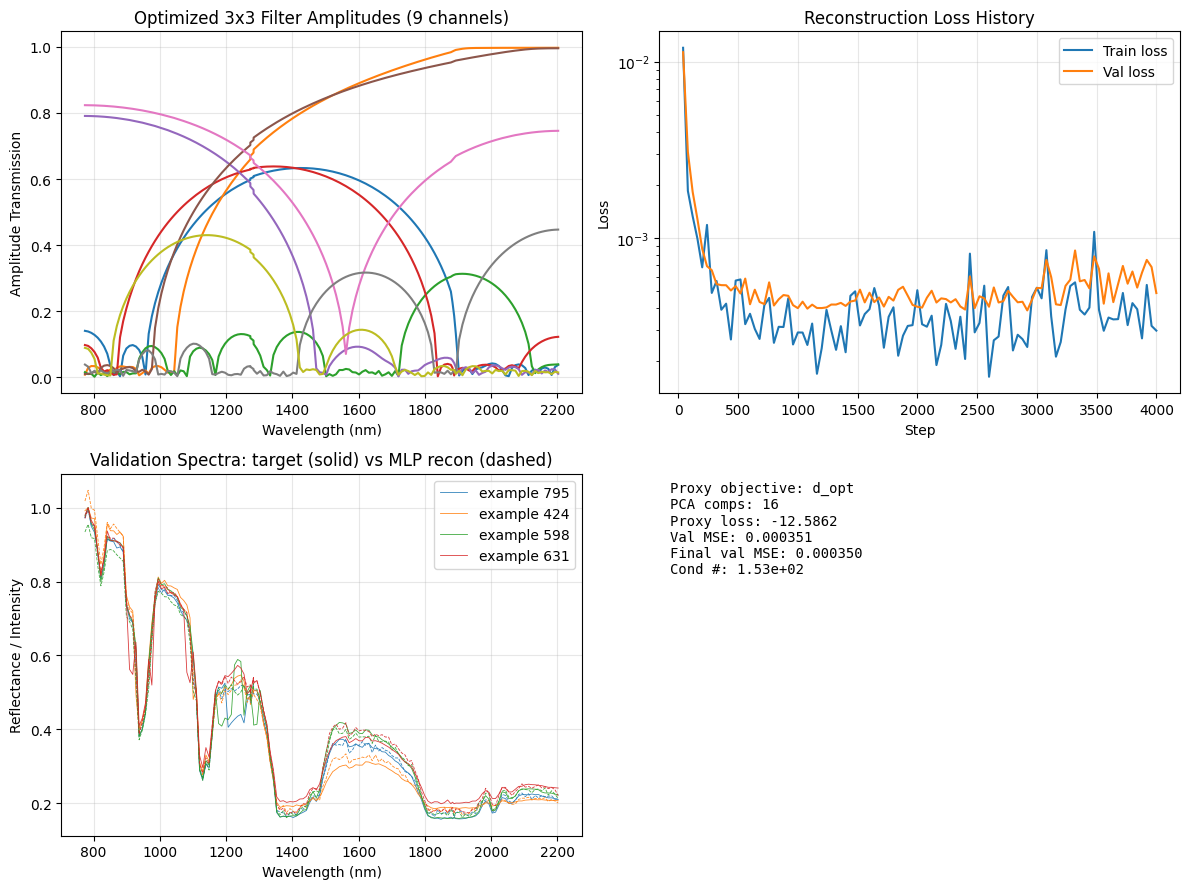

saved: artifacts/spectral_filter_overview.png


In [9]:
if PLOT:
    wavelengths_np = np.asarray(wavelengths_nm)
    n_examples = min(4, val.shape[0])
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    for i in range(num_filters):
        axes[0, 0].plot(wavelengths_np, filt_amp_opt[i], linewidth=1.5)
    axes[0, 0].set_title(
        f"Optimized {ARRAY_SIZE}x{ARRAY_SIZE} Filter Amplitudes ({num_filters} channels)"
    )
    axes[0, 0].set_xlabel("Wavelength (nm)")
    axes[0, 0].set_ylabel("Amplitude Transmission")
    axes[0, 0].grid(alpha=0.3)

    ax = axes[0, 1]
    ax.plot(history_steps, history_train, label="Train loss")
    ax.plot(history_steps, history_val, label="Val loss")
    ax.set_title("Reconstruction Loss History")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    ax.set_yscale("log")

    random_indices = jax.random.choice(key, val.shape[0], (n_examples,), replace=False)
    for i in random_indices:
        idx = int(i)
        (line,) = axes[1, 0].plot(
            wavelengths_np,
            val[idx],
            alpha=0.9,
            linewidth=0.6,
            label=f"example {idx}",
        )
        axes[1, 0].plot(
            wavelengths_np,
            np.asarray(final_x_val_hat[idx]),
            alpha=0.9,
            linewidth=0.6,
            linestyle="--",
            color=line.get_color(),
        )
    axes[1, 0].set_title("Validation Spectra: target (solid) vs MLP recon (dashed)")
    axes[1, 0].set_xlabel("Wavelength (nm)")
    axes[1, 0].set_ylabel("Reflectance / Intensity")
    axes[1, 0].grid(alpha=0.3)
    axes[1, 0].legend()

    axes[1, 1].axis("off")
    axes[1, 1].text(
        0.02,
        0.98,
        (
            f"Proxy objective: d_opt\n"
            f"PCA comps: {pca_components}\n"
            f"Proxy loss: {best_proxy_loss:.4f}\n"
            f"Val MSE: {val_mse:.6f}\n"
            f"Final val MSE: {final_val_mse:.6f}\n"
            f"Cond #: {float(svals[0] / max(svals[-1], 1e-12)):.2e}"
        ),
        va="top",
        ha="left",
        fontsize=10,
        family="monospace",
    )

    fig.tight_layout()
    fig.savefig(PLOT_PATH, dpi=150)
    plt.show()
    print(f"saved: {PLOT_PATH}")
